In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# convert column name upper case to lower case
df.columns =df.columns.str.lower()
# replace blanks with zero
df['totalcharges']=df['totalcharges'].replace(' ','0')
# change datatype str to float
df['totalcharges']= df['totalcharges'].astype(float)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [7]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
# replace 0 or 1 into yes or no 
def conv(value):
    if value == 1:
        return "yes"
    else:
        return 'no'
    
    
df['seniorcitizen']=df['seniorcitizen'].apply(conv)

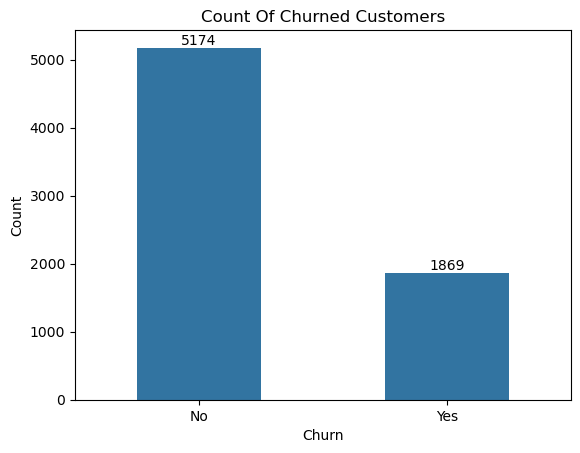

In [9]:
ax=sns.countplot(x=df['churn'], width=0.5)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Count Of Churned Customers')
for i in ax.containers:
    ax.bar_label(i)
plt.show()

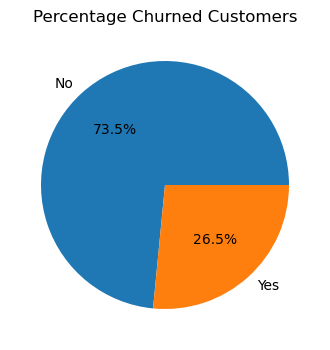

In [10]:
churn_gb=df.groupby('churn').agg({'churn':'count'})
plt.figure(figsize=(4,7))
plt.pie(churn_gb['churn'], labels= churn_gb.index, autopct='%1.1f%%')
plt.title('Percentage Churned Customers')
plt.show()

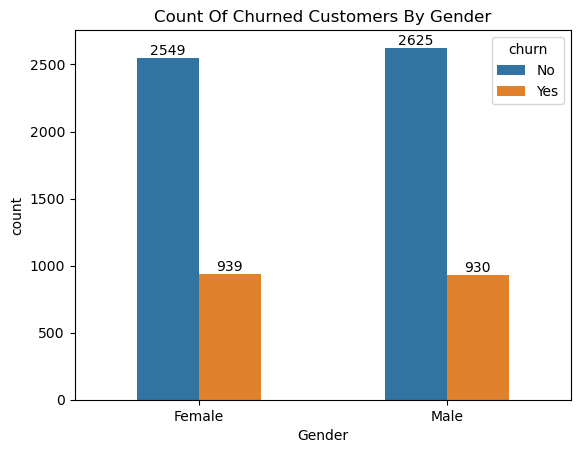

In [11]:
plt.Figure(figsize=(4,3))
gx=sns.countplot(x='gender',data= df , hue= 'churn', width=0.5)
plt.title('Count Of Churned Customers By Gender')
plt.xlabel('Gender')

for i in gx.containers:
    gx.bar_label(i) 
plt.show()

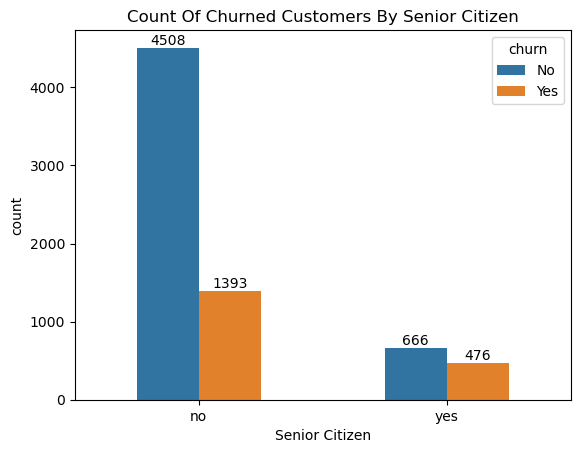

In [12]:
plt.Figure(figsize=(4,3))
sx=sns.countplot(x='seniorcitizen',data= df , hue= 'churn', width=0.5)
plt.title('Count Of Churned Customers By Senior Citizen')
plt.xlabel('Senior Citizen')

for i in sx.containers:
    sx.bar_label(i) 
plt.show()

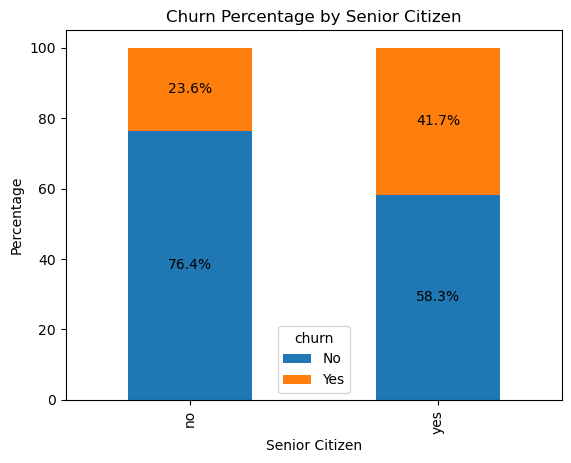

In [13]:
data= df.groupby(['seniorcitizen','churn']).size().unstack()
data_pct= data.div(data.sum(axis=1),axis= 0)*100

plt.Figure(figsize=(3,3))
sn=data_pct.plot(kind='bar',stacked=True)
for container in sn.containers:
    sn.bar_label(container, fmt='%.1f%%', label_type='center')

    plt.title('Churn Percentage by Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage')
plt.show()

comparative a greater percentage of people in senior citizen category have churned 

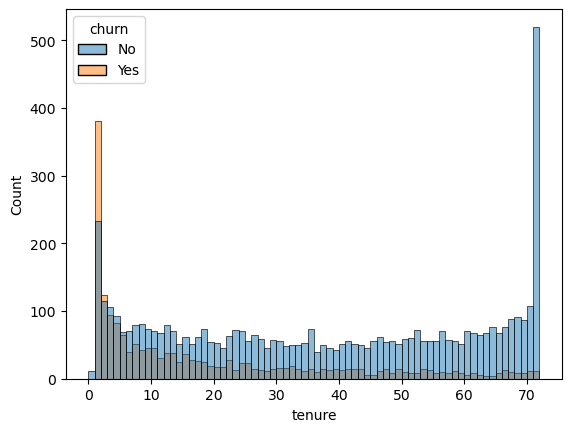

In [14]:
plt.Figure(figsize=(9,4))
sns.histplot(x='tenure', data= df, bins=72, hue= 'churn')
plt.show()

people who have used our services for a long time have stayed and people who have used our services 1 or 2 months have churned

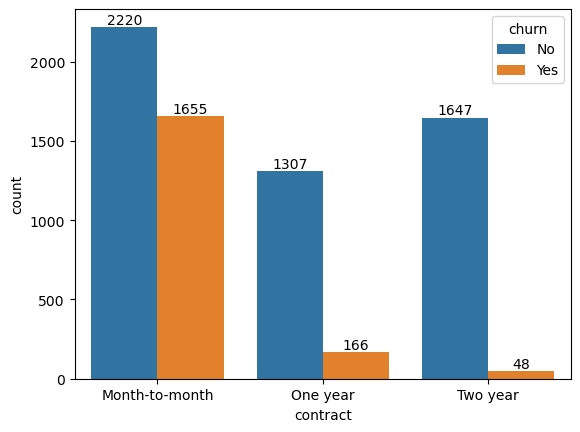

In [15]:
plt.Figure(figsize=(4,4))
cn=sns.countplot(x= 'contract', data= df, hue= 'churn')
for i in cn.containers:
    cn.bar_label(i)
plt.show()

people who have month to month contract are likely to churn then for those who have 1 year or 2 year contract

In [16]:
df.columns.values

array(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod', 'monthlycharges',
       'totalcharges', 'churn'], dtype=object)

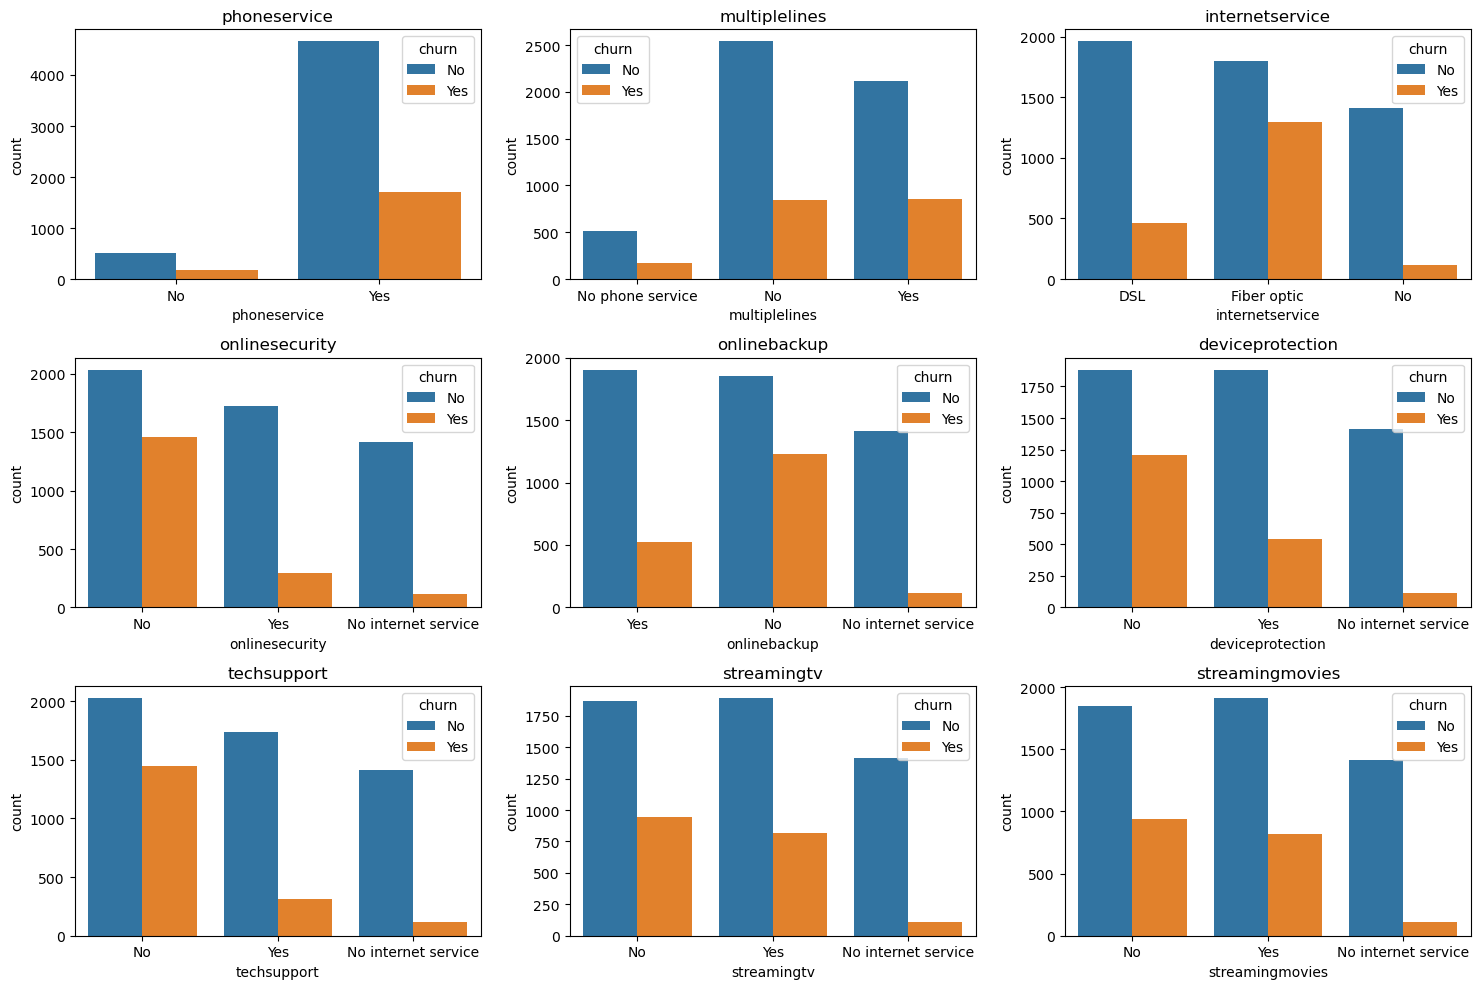

In [20]:
cols = [
    'phoneservice', 'multiplelines', 'internetservice',
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)   
    sns.countplot(x=col, data=df, hue='churn')
    plt.title(col)

plt.tight_layout()
plt.show()

Most customers use phone service and multiple lines, with lower churn overall.

 Fiber optic users have higher churn compared to DSL users.

 Extra services like security, support, and protection reduce churn.

 Customers without internet service show very low churn.

 Overall, more services lead to better customer retention. 

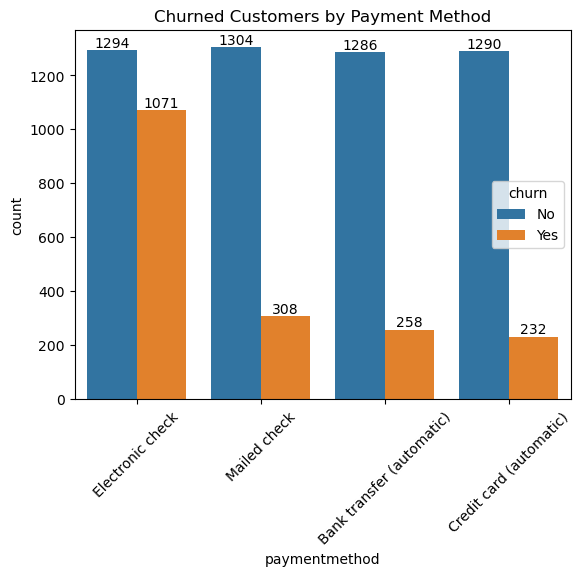

In [22]:
plt.Figure(figsize=(9,6))
pm=sns.countplot(x='paymentmethod', data=df, hue='churn')

for i in pm.containers:
    pm.bar_label(i)

plt.title('Churned Customers by Payment Method')
plt.xticks(rotation=45)
plt.show()

customer is likely to churn when he is using electronic check as a payment method